# Set-Up
Package and data importing

In [11]:
import warnings
import pandas as pd

from series_analysis import (
    run_stationarity_tests,
    summarize_stationarity,
    plot_stationarity_heatmap,
    run_ljung_box_tests,
    summarize_ljung_box,
    plot_ljung_box_heatmap,
    first_difference,
)
from data_analysis import plot_acf_grid
from visualization import plot_lexical_metrics

warnings.filterwarnings("ignore")

In [ ]:
# Path to the combined CSV written by combine_lexical_csvs.py.
# Edit to match your local or cluster path before running.
CSV_PATH = "/scratch/network/nv9344/Thesis/Thesis-Data/ArcticShift/lexical_df_combined.csv"

# raw_text is excluded via usecols to cut down read time
COLS_TO_LOAD = [
    "utterance_id",
    "speaker_id",
    "subreddit",
    "timestamp",
    "year_month",
    "mtld_score",
    "mattr_score",
    "yules_k",
    "zipf_score",
    "aoa_score",
    "nawl_ratio",
]

METRICS = ["mtld_score", "mattr_score", "yules_k", "zipf_score", "aoa_score", "nawl_ratio"]

df = pd.read_csv(CSV_PATH, usecols=COLS_TO_LOAD, low_memory=False)

# --- Preprocessing ---
# The ArcticShift pipeline stores timestamps as datetime strings (not Unix ints),
# so no unit= argument is needed here. Using unit="s" on a string coerces
# everything to NaT, which produces blank plots.
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Normalise subreddit casing — ArcticShift preserves Reddit's original casing
# (e.g. "Parenting"), so lowercase everything for consistency across plots.
df["subreddit"] = df["subreddit"].str.lower()

# Coerce metric columns to numeric
for m in METRICS:
    df[m] = pd.to_numeric(df[m], errors="coerce")

# Drop rows where fewer than 2 of the 6 metrics are valid
valid_count = df[METRICS].notna().sum(axis=1)
df = df[valid_count >= 2].reset_index(drop=True)

print(f"Loaded {len(df):,} utterances across {df['subreddit'].nunique()} subreddit(s).")
print(df.groupby("subreddit")["year_month"].nunique().rename("n_months").to_frame().T)

# Temporal Analysis
Examine the trends of each metric—all positively correlated with lexical quality—over time

## Initial Visualization

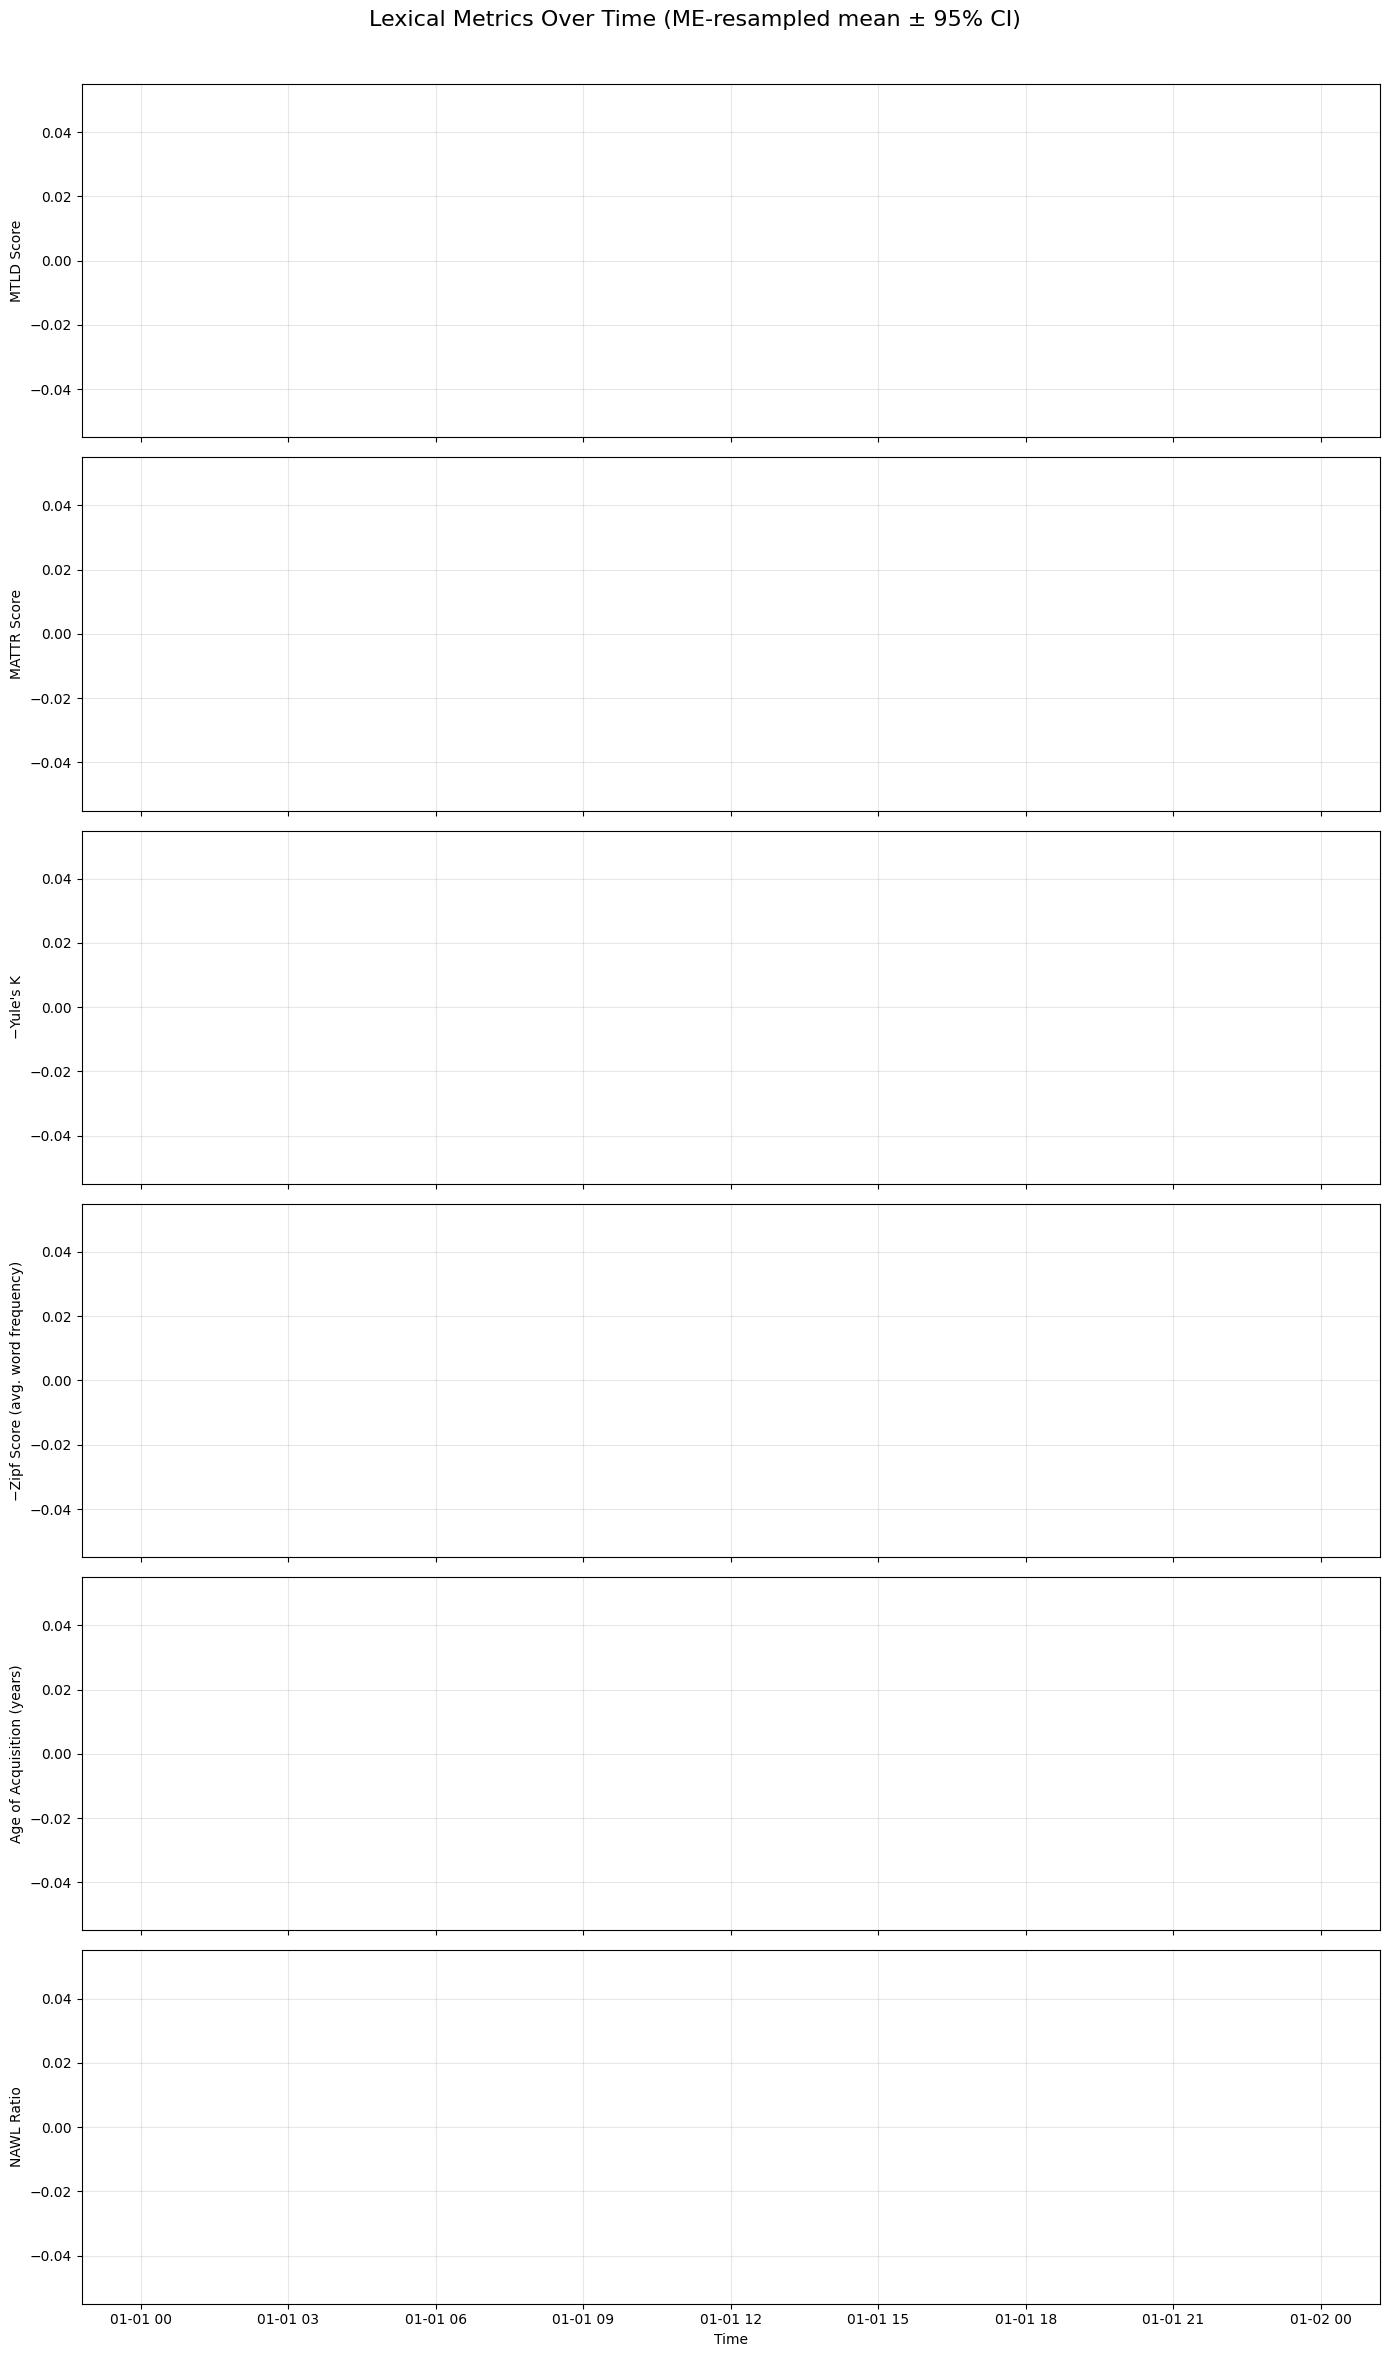

In [13]:
plot_lexical_metrics(df, resample_freq='ME', agg='mean')

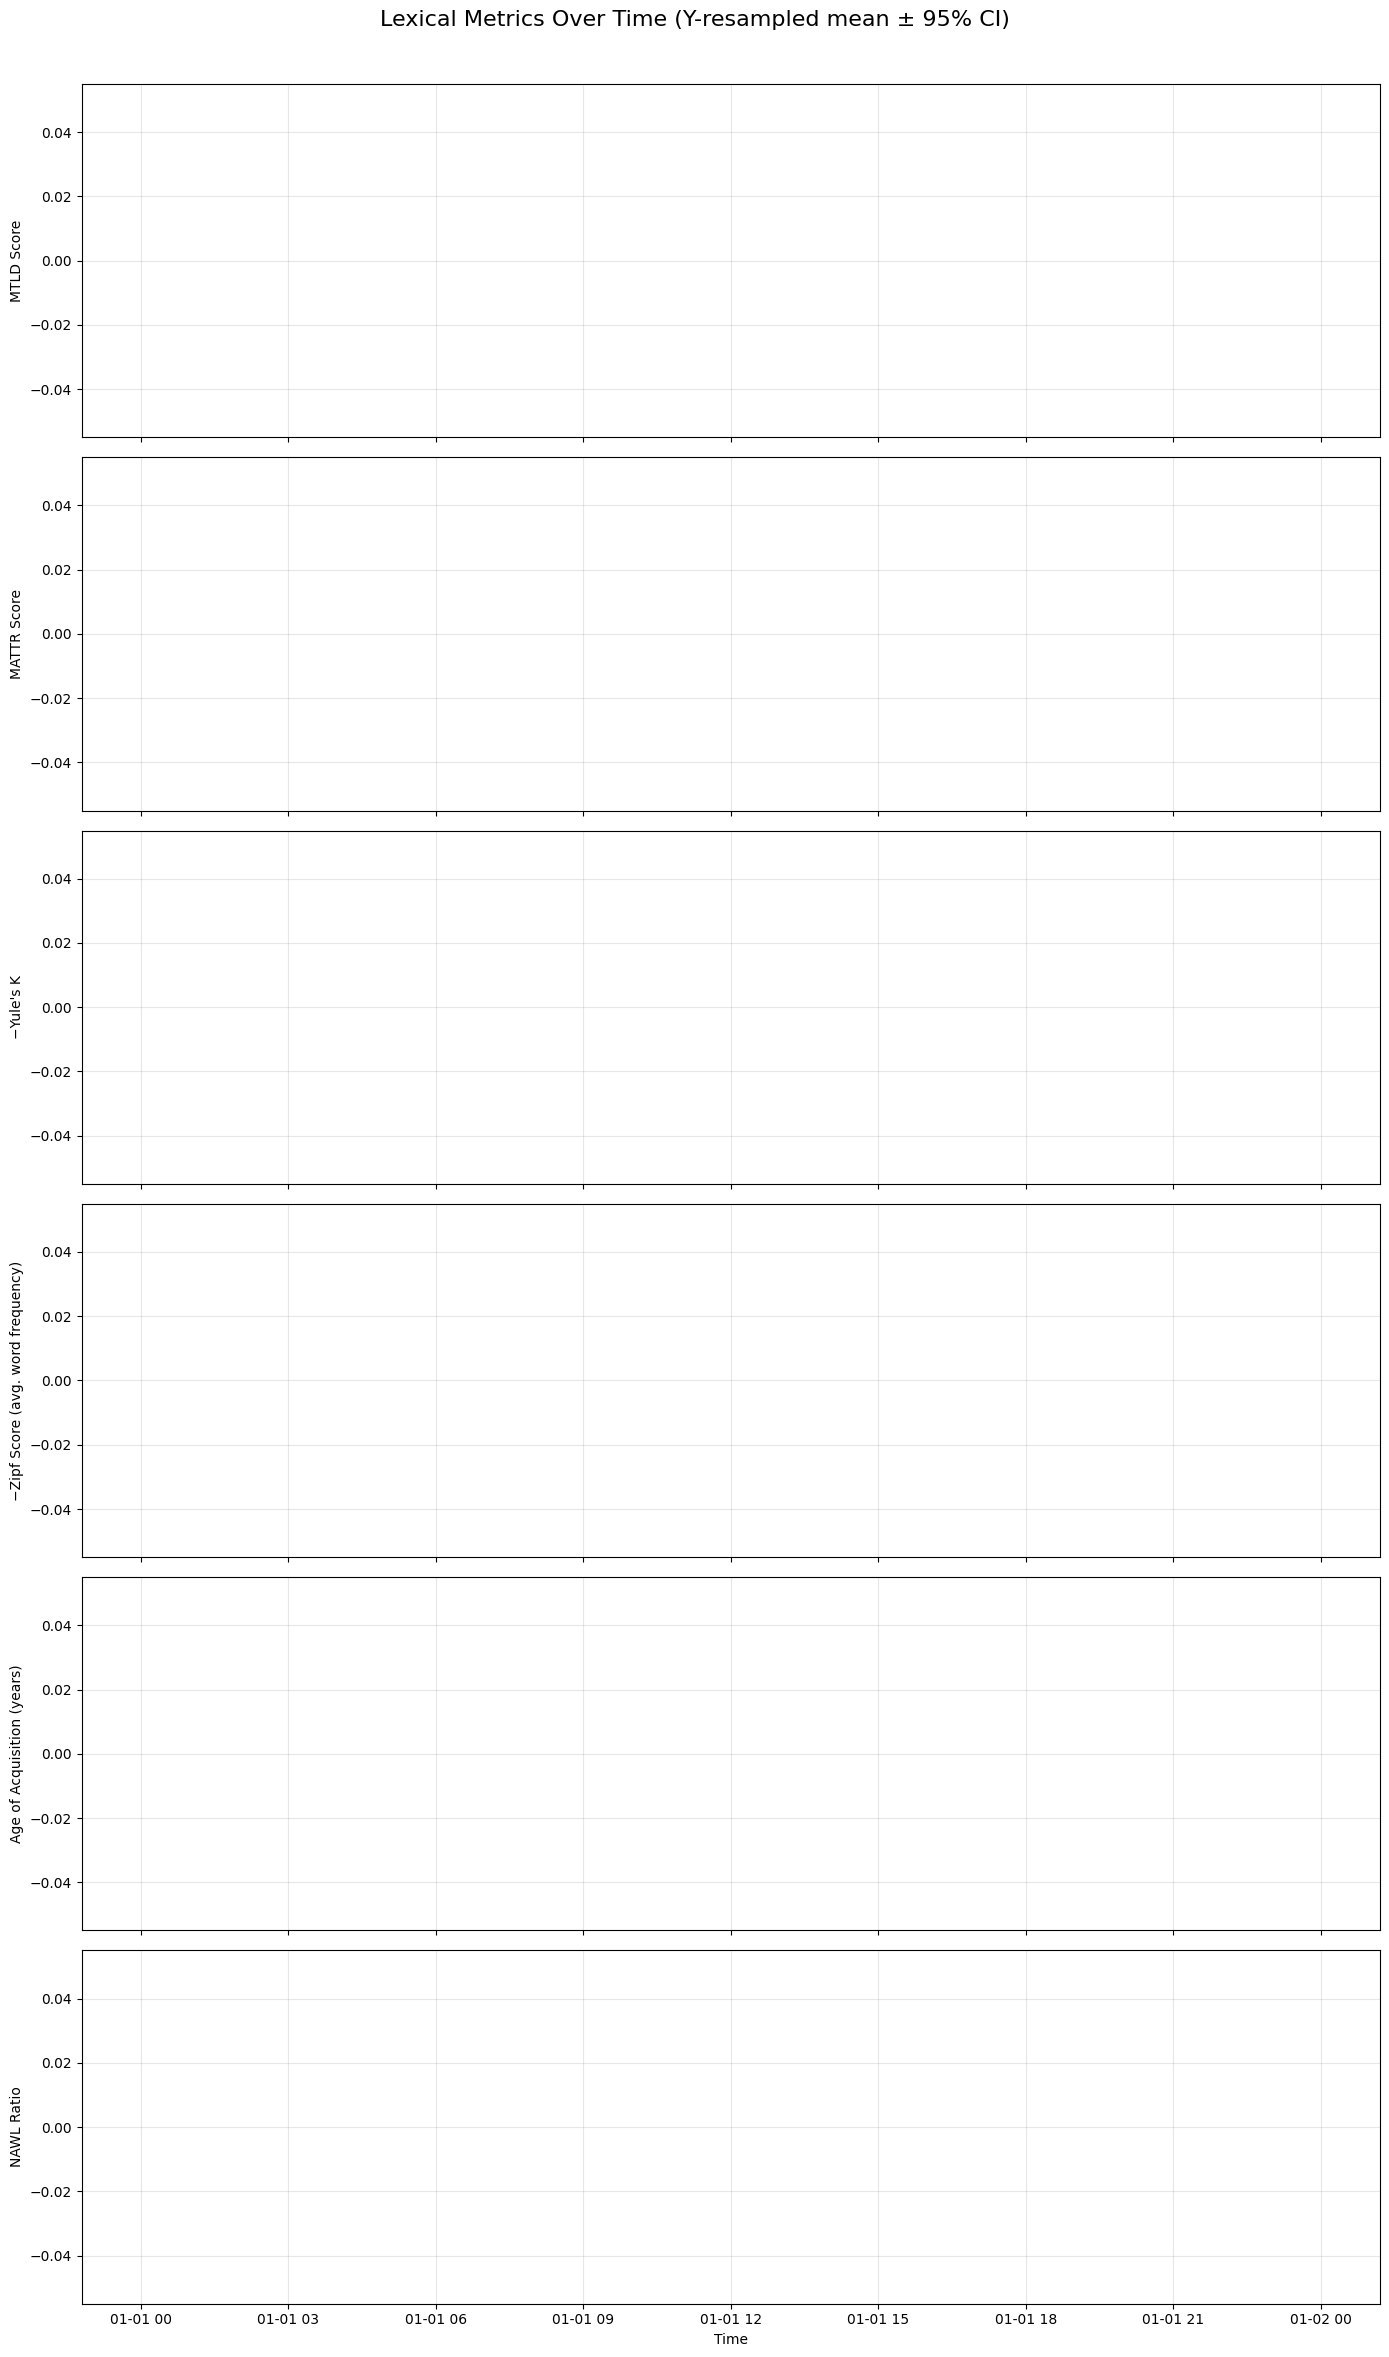

In [14]:
plot_lexical_metrics(df, resample_freq='Y', agg='mean')

## Aggregation
Aggregate to the subreddit-month level

In [15]:
# aggregate and sort
agg = df.groupby(["subreddit", "year_month"])[METRICS].mean().reset_index()
agg = agg.sort_values(["subreddit", "year_month"])

In [16]:
# filter subreddits with insufficient time series length
# ArcticShift spans ~2005-2023 (~216 months max), so 80 obs is a conservative floor
min_obs = 80  # based on DeJong study
counts = agg.groupby("subreddit")["year_month"].count()
valid_subreddits = counts[counts >= min_obs].index
agg = agg[agg["subreddit"].isin(valid_subreddits)]

print(f"Subreddits passing min_obs={min_obs} filter: {sorted(valid_subreddits.tolist())}")
print(counts[counts >= min_obs].rename("n_months").to_frame())

Subreddits passing min_obs=80 filter: ['college', 'parenting', 'retirement', 'teenagers']
            n_months
subreddit           
college          135
parenting        137
retirement       136
teenagers        137


## Pre-Regression Analysis
Confirm the series is stationary and not autocorrelated, adjusting as necessary

### Stationarity Tests
ADF and KPSS tests

=== Stationarity Test Summary ===
Total (subreddit × metric) series tested: 24

Overall conclusions:
  stationary                                4  (16.7%)
  unit root                                12  (50.0%)
  inconclusive (both reject)                6  (25.0%)
  inconclusive (neither rejects)            2  (8.3%)
  insufficient data                         0  (0.0%)

Breakdown by metric:
  MTLD               → most common: unit root
  MATTR              → most common: unit root
  Yule's K           → most common: inconclusive (both reject)
  Zipf Score         → most common: inconclusive (both reject)
  AoA                → most common: unit root
  NAWL Ratio         → most common: unit root


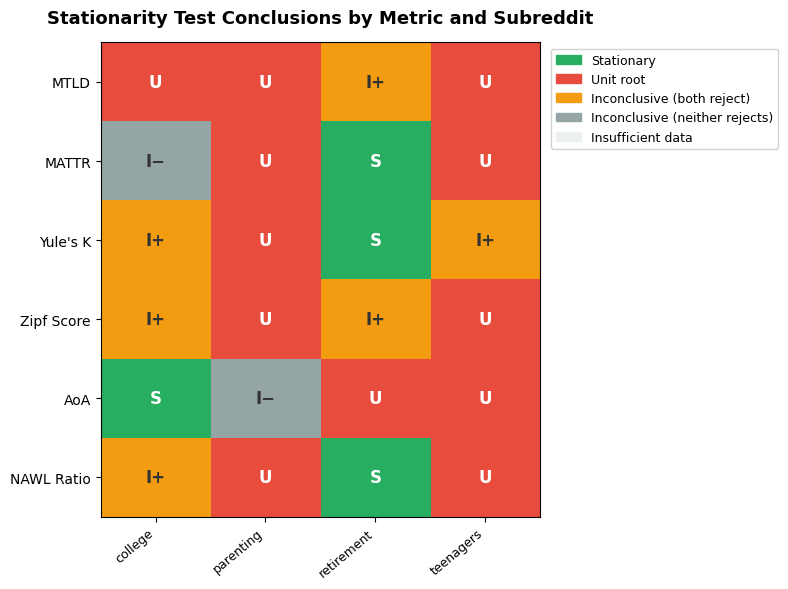

In [17]:
stationarity_results = run_stationarity_tests(agg)
summarize_stationarity(stationarity_results)
plot_stationarity_heatmap(stationarity_results)

### Autocorrelation Tests
Determine if the series is autocorrelated

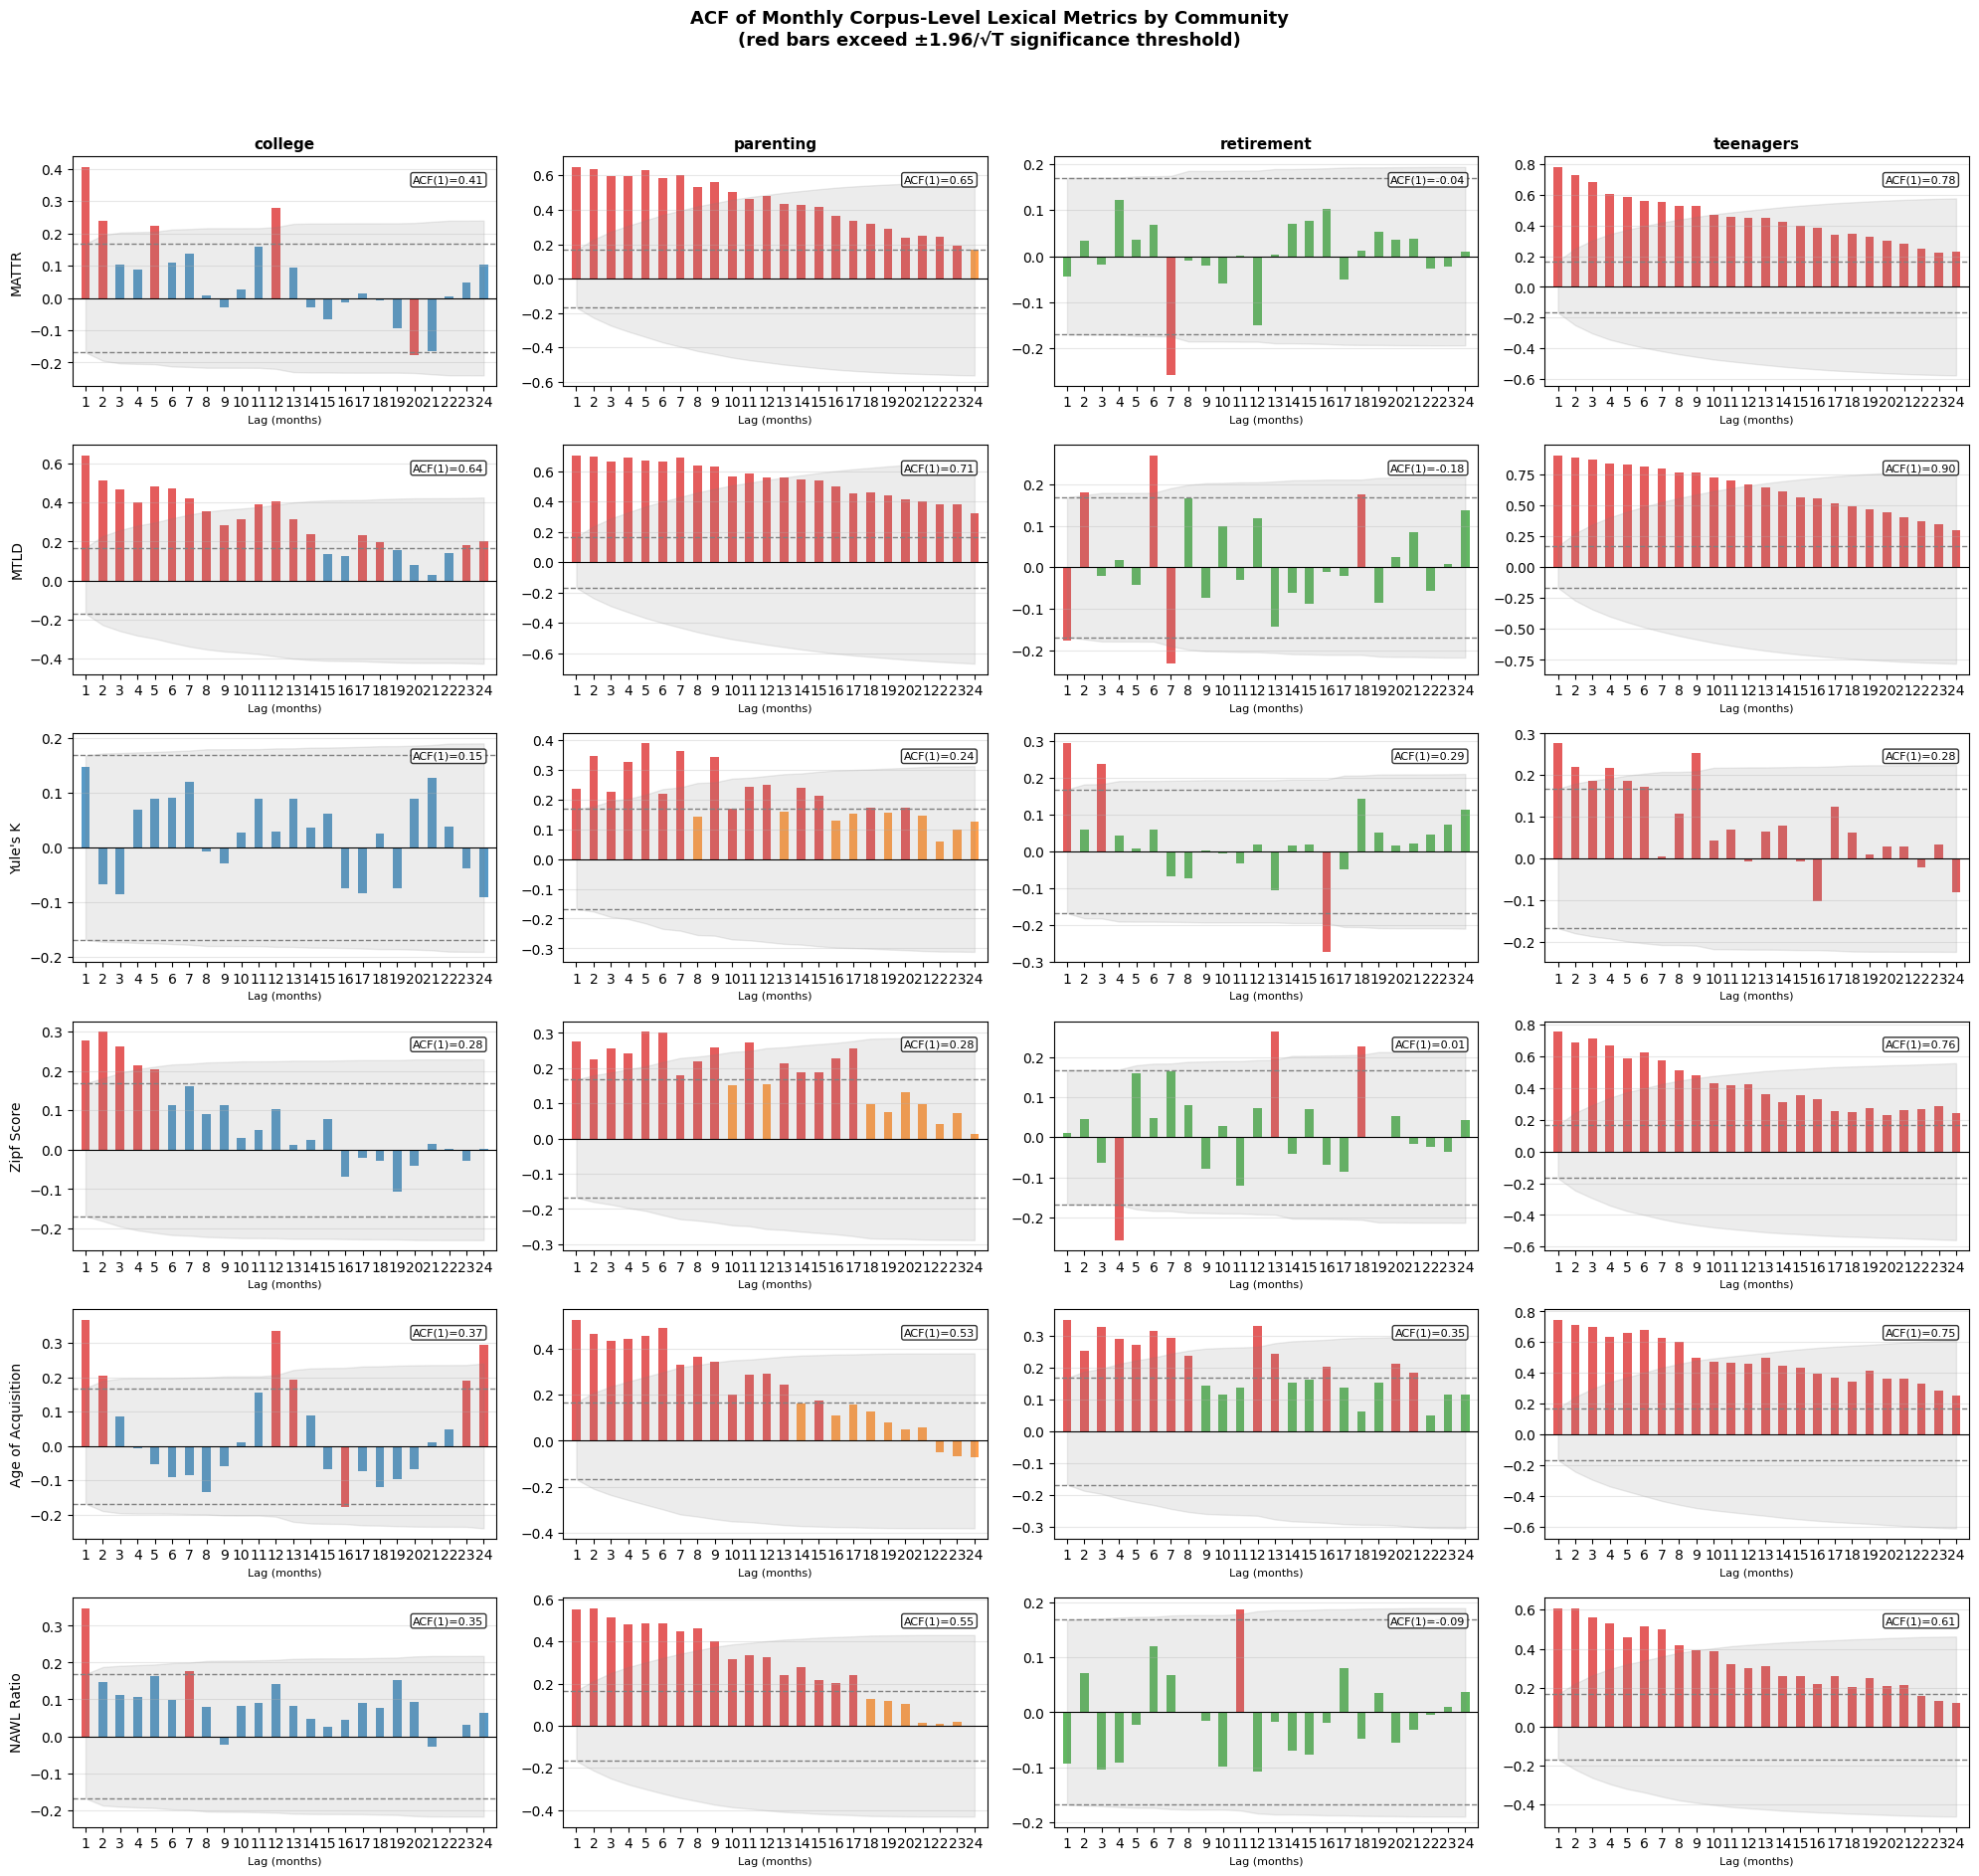

In [18]:
plot_acf_grid(agg, n_lags=24)

=== Ljung-Box Autocorrelation Test Summary ===
Lags tested: h=12, h=6   |   Conclusion based on: h=6
Total (subreddit × metric) series tested: 24

Overall conclusions:
  no autocorrelation           3  (12.5%)
  autocorrelated              21  (87.5%)
  insufficient data            0  (0.0%)

Breakdown by metric:
  MTLD               → most common: autocorrelated
  MATTR              → most common: autocorrelated
  Yule's K           → most common: autocorrelated
  Zipf Score         → most common: autocorrelated
  AoA                → most common: autocorrelated
  NAWL Ratio         → most common: autocorrelated


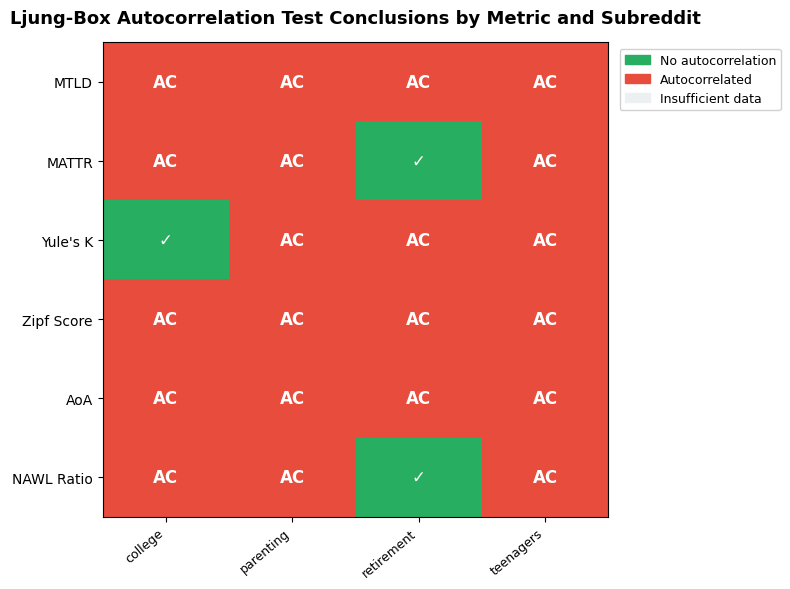

In [19]:
lb_results = run_ljung_box_tests(agg)
summarize_ljung_box(lb_results)
plot_ljung_box_heatmap(lb_results)

### First-Differencing

=== Stationarity Test Summary ===
Total (subreddit × metric) series tested: 24

Overall conclusions:
  stationary                               24  (100.0%)
  unit root                                 0  (0.0%)
  inconclusive (both reject)                0  (0.0%)
  inconclusive (neither rejects)            0  (0.0%)
  insufficient data                         0  (0.0%)

Breakdown by metric:
  MTLD               → most common: stationary
  MATTR              → most common: stationary
  Yule's K           → most common: stationary
  Zipf Score         → most common: stationary
  AoA                → most common: stationary
  NAWL Ratio         → most common: stationary


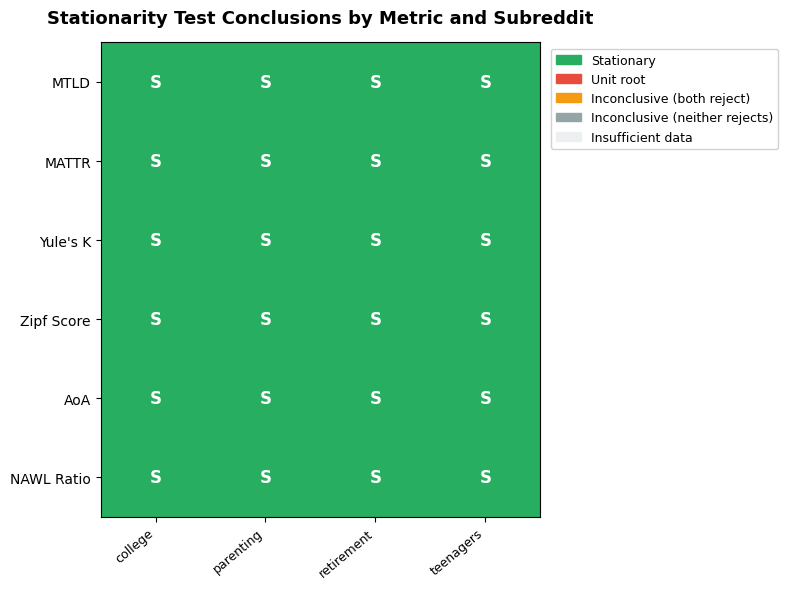

In [20]:
agg_diff = first_difference(agg)
stationarity_results_diff = run_stationarity_tests(agg_diff)   # should now show stationary
summarize_stationarity(stationarity_results_diff)
plot_stationarity_heatmap(stationarity_results_diff)